# **LangGraph 101: Building Stateful AI Workflows**

In [84]:
import random
import string
from typing import TypedDict

from langgraph.graph import StateGraph, END

class ChainState(TypedDict):
    n: int
    letter: str

initial_state = ChainState(n=1, letter='a')
print(initial_state)

def add(state: ChainState) -> ChainState:
    random_letter = random.choice(string.ascii_lowercase)
    return {**state, "n": state["n"]+1, "letter": random_letter,}

def print_out(state: ChainState) -> ChainState:
    print("Current n:", state["n"], "letter:" ,state["letter"])
    return state

def stop_condition(state: ChainState) -> bool:
    return state["n"] >= 13

{'n': 1, 'letter': 'a'}


In [85]:
from langgraph.graph import StateGraph, END

workflow = StateGraph(ChainState)
workflow.add_node("add", add)
workflow.add_node("print", print_out)
workflow.add_edge("add", "print")
workflow.add_conditional_edges("print", stop_condition,
{
    True: END,
    False: "add"
})

workflow.set_entry_point("add")
app = workflow.compile()
result = app.invoke({"n":1, "letter":""})
# state: {'n':1, "letter":''}


Current n: 2 letter: b
Current n: 3 letter: u
Current n: 4 letter: g
Current n: 5 letter: b
Current n: 6 letter: r
Current n: 7 letter: h
Current n: 8 letter: h
Current n: 9 letter: a
Current n: 10 letter: x
Current n: 11 letter: i
Current n: 12 letter: a
Current n: 13 letter: g


In [86]:
import os
import dotenv
from langchain_openai import ChatOpenAI
from langchain_ibm import ChatWatsonx

dotenv.load_dotenv()

llm = ChatOpenAI(
    model = "gpt-4.1-nano",
    api_key = os.getenv("OPEN_AI_KEY"),
)

# watsonx_llm = ChatWatsonx(
#     model_id="ibm/granite-3-2-8b-instruct",
#     url="https://api.ap-south-1.dl.watson-orchestrate.ibm.com/instances/20251212-2008-2496-2060-3f686fc39c52",
#     project_id="your project id associated with the API key",
#     api_key=os.getenv("WATSONX_API_KEY"),
# )

## Components of LangGraph

In this example, we are defining a state structure for a **user authentication workflow**. The state, called `AuthState`, is a typed dictionary that holds information about a user's credentials (username and password) and their authentication status (`is_authenticated`) as shown here:

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/dhl478pwbZzrxzmcjJY4xw/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM.png" alt="Screenshot" width="300">
</div>


### 1. States

In [87]:
from typing import TypedDict, Optional

class AuthState(TypedDict):
    username: Optional[str]
    password: Optional[str]
    is_authenticated: Optional[bool]
    output: Optional[str]

#### Example Objects and Their States
##### Object 1: Successful Login

In [88]:
auth_state_1: AuthState = {
    "username" : "John",
    "password" : "Password_1",
    "is_authenticated" : True,
    "output" : "Login successful"
}
print(f"auth_state1: {auth_state_1}")

auth_state1: {'username': 'John', 'password': 'Password_1', 'is_authenticated': True, 'output': 'Login successful'}


##### Object 2: Unsuccessful Login

In [89]:
auth_state_2: AuthState = {
    "username" : "",
    "password" : "wrongPassword",
    "is_authenticated" : False,
    "output" : "Authentication failed. Please try again"
}
print(f"auth_state2: {auth_state_2}")

auth_state2: {'username': '', 'password': 'wrongPassword', 'is_authenticated': False, 'output': 'Authentication failed. Please try again'}


### 2. Nodes
Nodes are the **core units of action** in LangGraph. Each node represents a specific task or operation that the AI agent needs to perform

#### Input Node

In [90]:
def input_node(state):
    print(state)
    if state.get('username', "") == "":
        state['username'] = input("What is your username?")

    password = input("Enter your password?")
    return {"password": password}

In [91]:
input_node(auth_state_1)

{'username': 'John', 'password': 'Password_1', 'is_authenticated': True, 'output': 'Login successful'}


{'password': 'password'}

In [92]:
input_node(auth_state_2)

{'username': '', 'password': 'wrongPassword', 'is_authenticated': False, 'output': 'Authentication failed. Please try again'}


{'password': 'password'}

#### Validate credential node

In [93]:
def validate_credentials_node(state):
    username = state.get("username", "")
    password = state.get("password", "")

    print("Username: ", username, "Password: ", password)

    if username == "test_user" and password == "secure_password":
        is_authenticated = True
    else:
        is_authenticated = False

    return {"is_authenticated": is_authenticated}

##### Validate node with incorrect format

In [94]:
validate_credentials_node(auth_state_1)

Username:  John Password:  Password_1


{'is_authenticated': False}

Validate node with correct format

In [95]:
auth_state_3: AuthState = {
    "username":"test_user",
    "password":  "secure_password",
    "is_authenticated": False,
    "output": "Authentication failed. Please try again."
}
print(f"auth_state_3: {auth_state_3}")

auth_state_3: {'username': 'test_user', 'password': 'secure_password', 'is_authenticated': False, 'output': 'Authentication failed. Please try again.'}


In [96]:
validate_credentials_node(auth_state_3)

Username:  test_user Password:  secure_password


{'is_authenticated': True}

#### Success node

In [97]:
def success_node(state):
    return {"output": "Authentication successful! Welcome!"}

In [98]:
success_node(auth_state_3)

{'output': 'Authentication successful! Welcome!'}

#### Failure node

In [99]:
def failure_node(state):
    return {"output": "Authentication failed. Please try again"}

#### Router node

In [100]:
def router(state):
    if state["is_authenticated"]:
        return "success_node"

    return "failure_node"

### Graph

In [101]:
from langgraph.graph import StateGraph, END
workflow = StateGraph(AuthState)
workflow

#### Add nodes to the graph

In [102]:
workflow.add_node("input_node", input_node)
workflow.add_node("validate_credentials_node", validate_credentials_node)
workflow.add_node("success_node", success_node)
workflow.add_node("failure_node", failure_node)

### 3. Edges

#### Connect the nodes

In [103]:
workflow.add_edge("input_node", "validate_credentials_node")
workflow.add_edge("success_node", END)
workflow.add_edge("failure_node", "input_node")

#### Conditional Edges

In [104]:
workflow.add_conditional_edges ("validate_credentials_node", router, {"success_node": "success_node", "failure_node": "failure_node"})

#### Setting the entry point

In [105]:
workflow.set_entry_point("input_node")

#### Compile the workflow

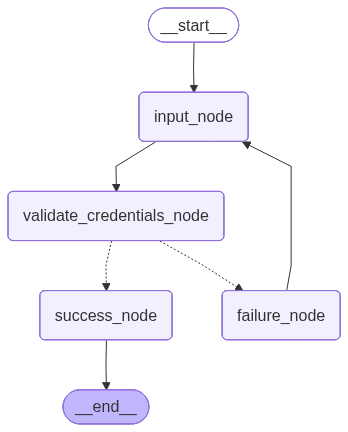

In [106]:
workflow.compile()